# Exploratory Data Analysis (EDA) and Visualization

## Tasks Performed
- Pollution trend analysis
- Top polluted cities analysis
- Pollutant distribution analysis
- Correlation analysis
- Heatmap visualization
- State-wise pollution analysis
- Pairplot visualization
- Time-based analysis

In [4]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [6]:
# ==========================================
# Load Cleaned Dataset
# ==========================================

df = pd.read_csv("../data/cleaned_air_quality.csv")

df.head()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg,year,month,day,hour
0,India,Bihar,Begusarai,"Lohiyanagar, Begusarai - BSPCB",2025-11-27 09:00:00,25.427420,86.138861,NH3,4.0,5.0,5.0,2025,11,27,9
1,India,Bihar,Bettiah,"Kamalnath Nagar, Bettiah - BSPCB",2025-11-27 09:00:00,26.803650,84.519540,PM2.5,41.0,223.0,102.0,2025,11,27,9
2,India,Bihar,Bhagalpur,"DM Office_Kachari Chowk, Bhagalpur - BSPCB",2025-11-27 09:00:00,25.251013,86.989001,NO2,6.0,11.0,8.0,2025,11,27,9
3,India,Bihar,Bhagalpur,"Mayaganj, Bhagalpur - BSPCB",2025-11-27 09:00:00,25.265194,87.012947,PM2.5,54.0,113.0,80.0,2025,11,27,9
4,India,Bihar,Bhagalpur,"Mayaganj, Bhagalpur - BSPCB",2025-11-27 09:00:00,25.265194,87.012947,NH3,8.0,15.0,11.0,2025,11,27,9


In [3]:
# ==========================================
# Dataset Shape
# ==========================================

print(df.shape)

(3344, 15)


In [12]:
import os

os.makedirs("../images", exist_ok=True)

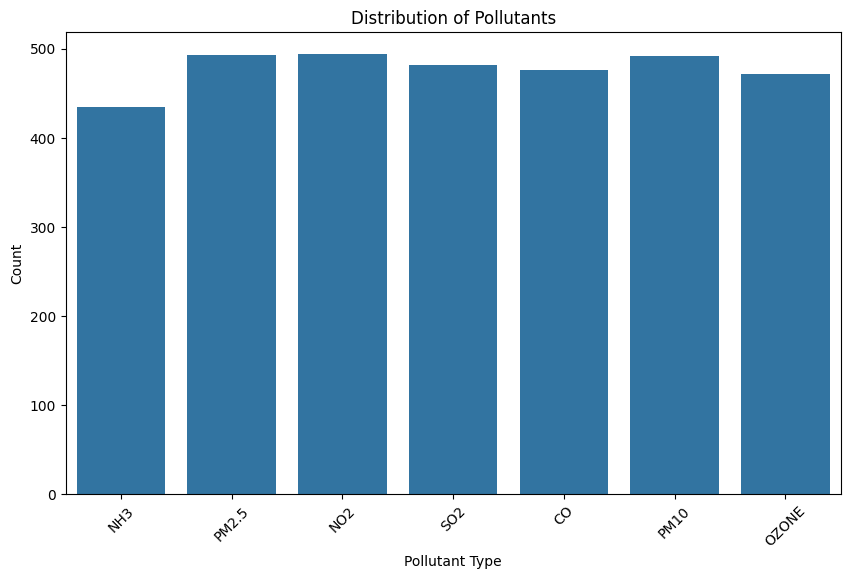

In [13]:
# ==========================================
# Pollutant Distribution
# ==========================================

plt.figure(figsize=(10,6))

sns.countplot(x='pollutant_id', data=df)

plt.title("Distribution of Pollutants")
plt.xlabel("Pollutant Type")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.savefig("../images/pollutant_distribution.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

### Observation

- PM2.5 and PM10 are among the most frequently occurring pollutants in the dataset.
- Some pollutants appear significantly more than others, indicating higher environmental concern.
- The distribution shows that air pollution monitoring focuses mainly on particulate matter pollutants.

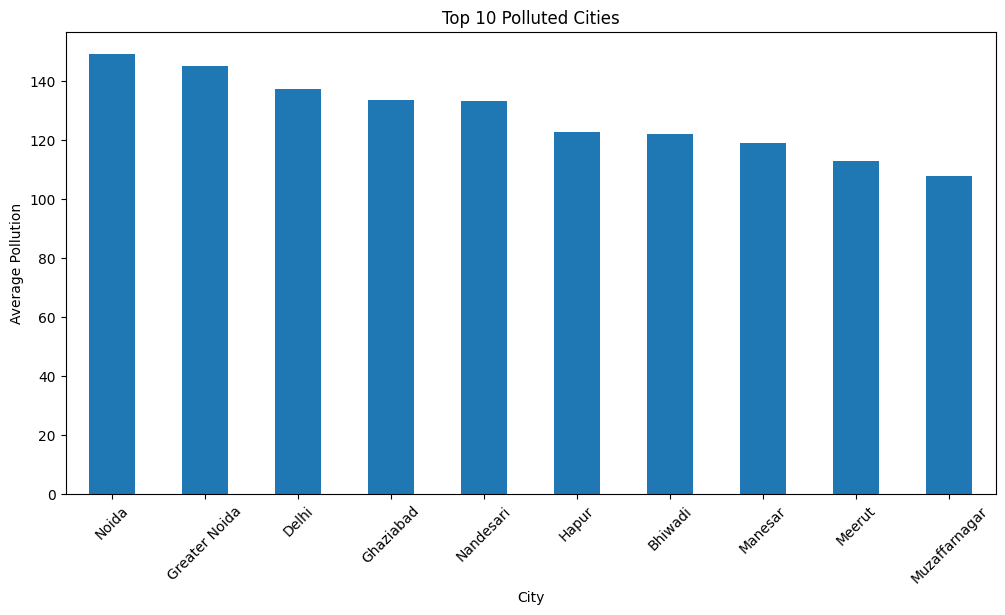

In [14]:
# ==========================================
# Top Polluted Cities
# ==========================================

top_cities = df.groupby('city')['pollutant_avg'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

top_cities.plot(kind='bar')

plt.title("Top 10 Polluted Cities")
plt.xlabel("City")
plt.ylabel("Average Pollution")

plt.xticks(rotation=45)

plt.savefig("../images/top_polluted_cities.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

### Observation

- Certain metropolitan cities show extremely high average pollution levels.
- Urbanization and industrial activities may contribute to increased pollution concentration.
- The graph helps identify high-risk pollution zones requiring environmental attention.

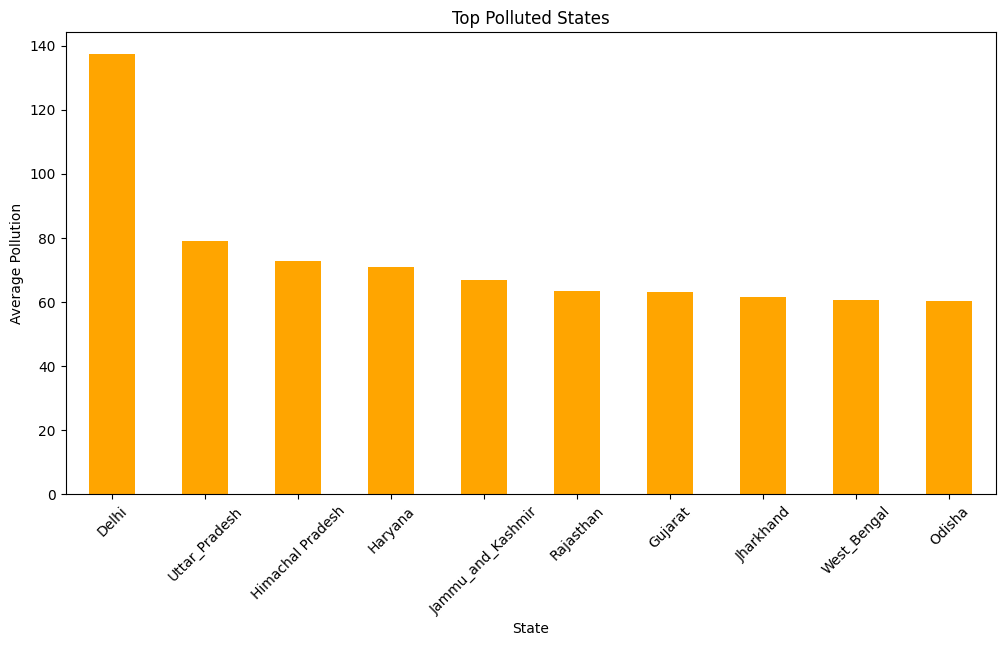

In [15]:
# ==========================================
# State-wise Pollution Analysis
# ==========================================

top_states = df.groupby('state')['pollutant_avg'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

top_states.plot(kind='bar', color='orange')

plt.title("Top Polluted States")
plt.xlabel("State")
plt.ylabel("Average Pollution")

plt.xticks(rotation=45)

plt.savefig("../images/state_pollution_analysis.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

### Observation

- Pollution levels vary significantly across different states.
- Industrial and densely populated states appear to have higher pollution averages.
- This analysis helps compare regional environmental conditions.

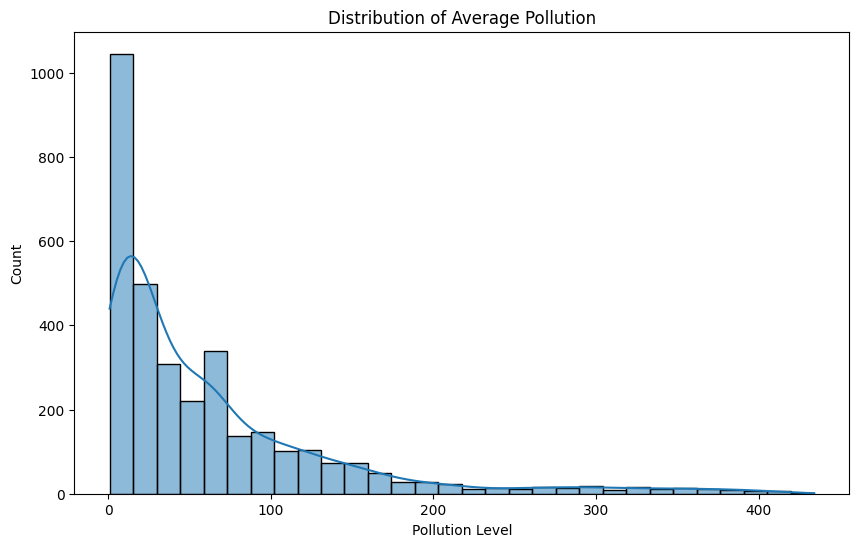

In [16]:
# ==========================================
# Pollution Distribution
# ==========================================

plt.figure(figsize=(10,6))

sns.histplot(df['pollutant_avg'], bins=30, kde=True)

plt.title("Distribution of Average Pollution")

plt.xlabel("Pollution Level")

plt.savefig("../images/pollution_distribution_histogram.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

### Observation

- The pollution data appears positively skewed.
- Most pollution values are concentrated within a moderate range, while some extreme values are present.
- The histogram indicates possible outliers in air quality measurements.

In [17]:
# ==========================================
# Correlation Matrix
# ==========================================

correlation = df[['pollutant_min',
                  'pollutant_max',
                  'pollutant_avg']].corr()

correlation

,pollutant_min,pollutant_max,pollutant_avg
pollutant_min,1.000000,0.807051,0.922094
pollutant_max,0.807051,1.000000,0.922755
pollutant_avg,0.922094,0.922755,1.000000


### Observation

- Pollutant minimum, maximum, and average values show strong positive relationships.
- As pollutant maximum values increase, average pollution levels also tend to increase.
- The correlation matrix helps understand dependency between pollution indicators.

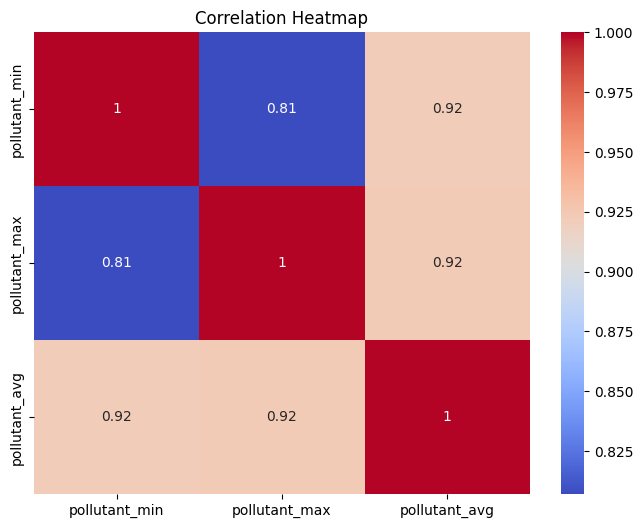

In [18]:
# ==========================================
# Heatmap
# ==========================================

plt.figure(figsize=(8,6))

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.savefig("../images/correlation_heatmap.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

### Observation

- Strong positive correlation is observed between pollutant_max and pollutant_avg.
- The heatmap visually represents relationships among pollution variables.
- Darker color intensity indicates stronger correlations between variables.

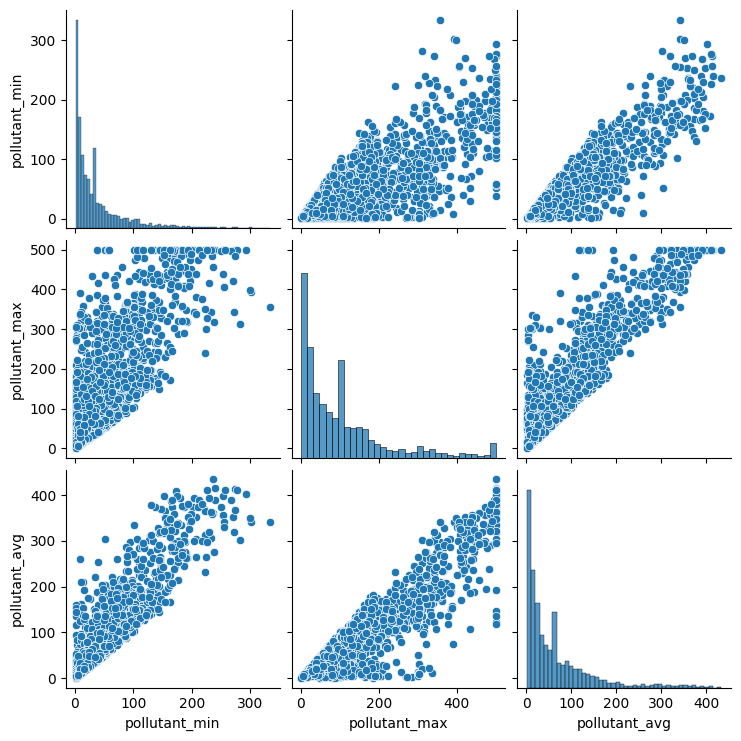

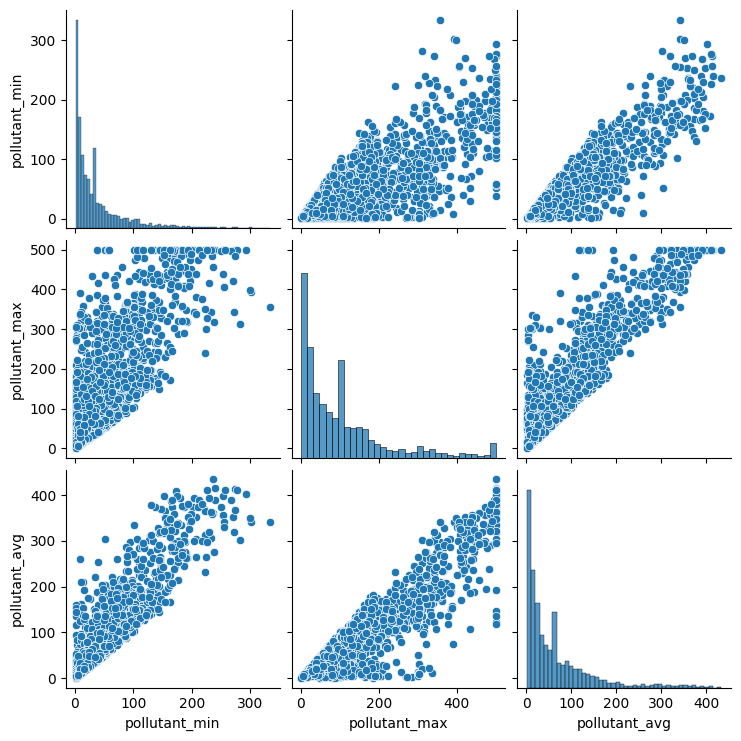

In [19]:
# ==========================================
# Pairplot
# ==========================================

sns.pairplot(df[['pollutant_min',
                 'pollutant_max',
                 'pollutant_avg']])

pairplot = sns.pairplot(df[['pollutant_min',
                            'pollutant_max',
                            'pollutant_avg']])

pairplot.savefig("../images/pairplot.png")

plt.show()

### Observation

- Pairwise relationships among pollutant variables show positive trends.
- Some variables exhibit linear relationships useful for machine learning models.
- The pairplot helps identify patterns, clusters, and potential outliers.

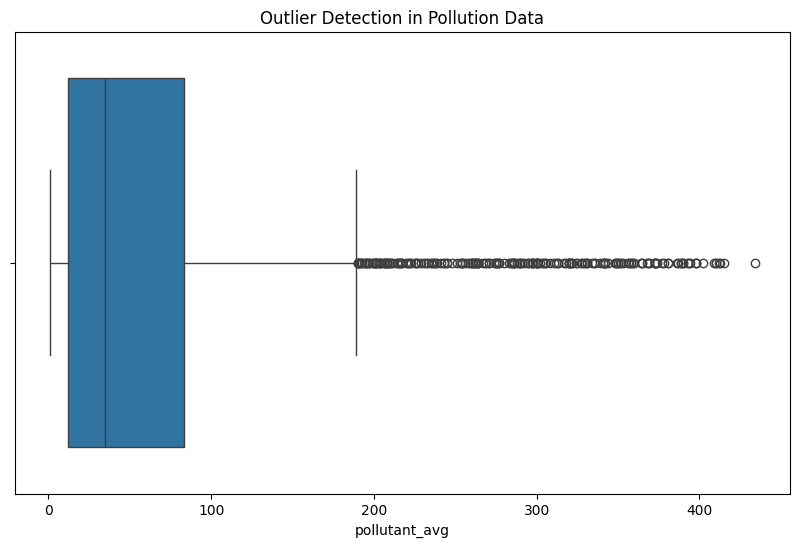

In [20]:
# ==========================================
# Boxplot for Outlier Detection
# ==========================================

plt.figure(figsize=(10,6))

sns.boxplot(x=df['pollutant_avg'])

plt.title("Outlier Detection in Pollution Data")

plt.savefig("../images/outlier_boxplot.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

### Observation

- Several outliers are present in pollutant average values.
- Extreme pollution levels may represent hazardous environmental conditions.
- Boxplots help detect abnormal observations in the dataset.

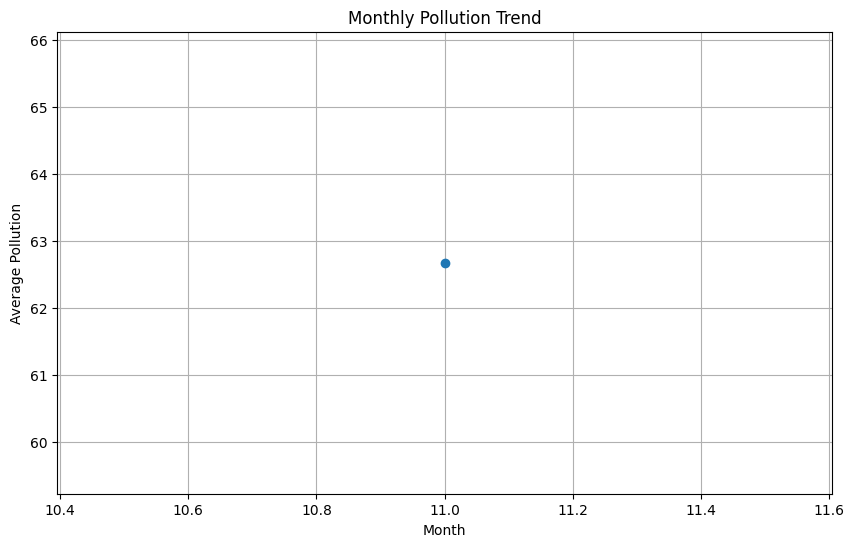

In [21]:
# ==========================================
# Monthly Pollution Trend
# ==========================================

monthly_pollution = df.groupby('month')['pollutant_avg'].mean()

plt.figure(figsize=(10,6))

monthly_pollution.plot(marker='o')

plt.title("Monthly Pollution Trend")

plt.xlabel("Month")
plt.ylabel("Average Pollution")

plt.grid(True)

plt.savefig("../images/monthly_pollution_trend.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

### Observation

- Pollution levels fluctuate across different months.
- Certain months show increased pollution levels, possibly due to seasonal effects.
- Trend analysis helps understand temporal changes in air quality.

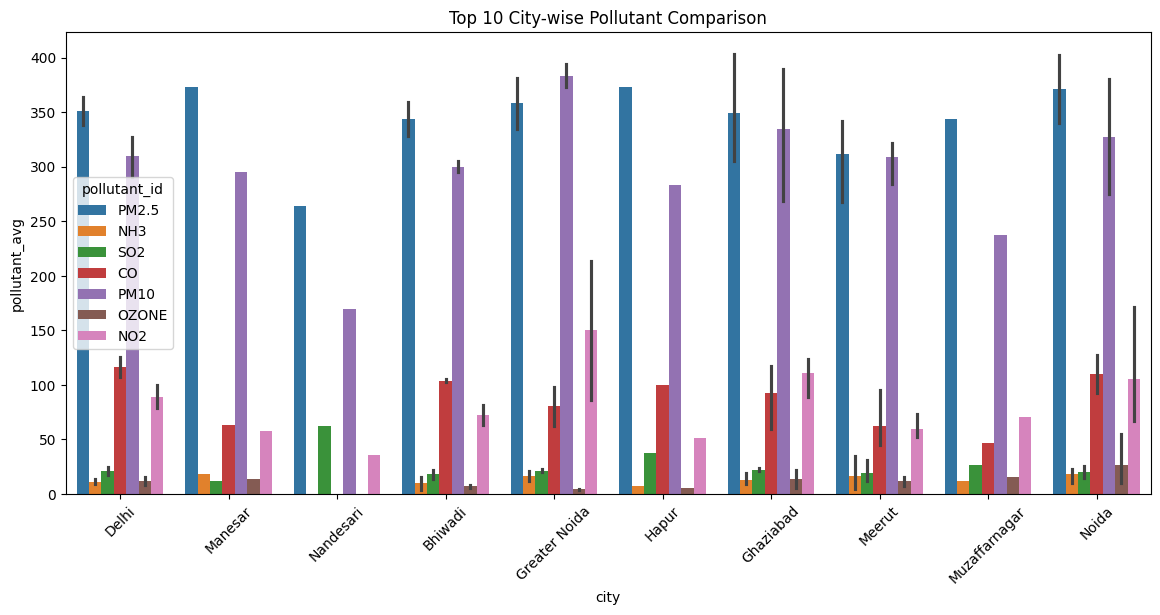

In [22]:
# ==========================================
# Top 10 City-wise Pollutant Comparison
# ==========================================

top10 = df.groupby('city')['pollutant_avg'].mean().sort_values(ascending=False).head(10).index

filtered_df = df[df['city'].isin(top10)]

plt.figure(figsize=(14,6))

sns.barplot(
    x='city',
    y='pollutant_avg',
    hue='pollutant_id',
    data=filtered_df
)

plt.xticks(rotation=45)

plt.title("Top 10 City-wise Pollutant Comparison")

plt.savefig("../images/city_pollutant_comparison.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

### Observation

- Different cities exhibit different dominant pollutants.
- Some cities show consistently higher pollutant averages across multiple pollutant types.
- This comparison highlights variations in pollution composition among cities.

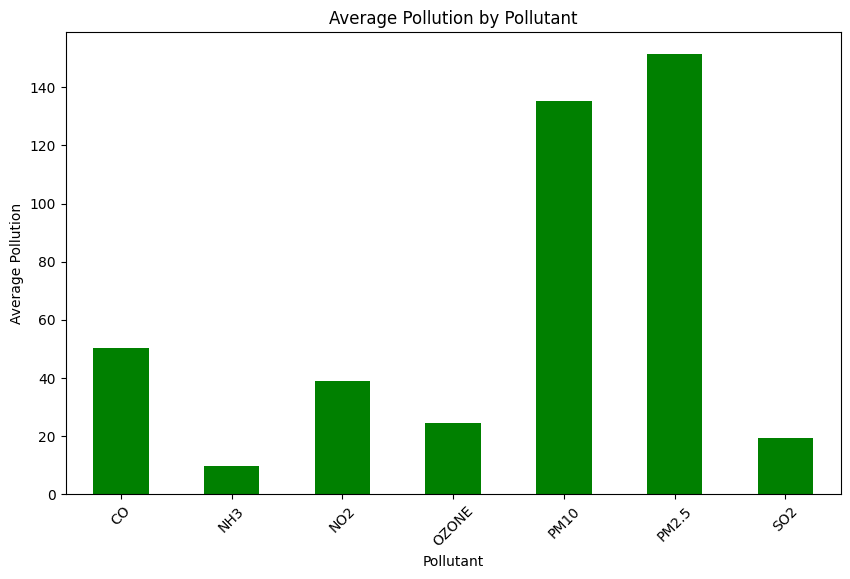

In [23]:
# ==========================================
# Average Pollution by Pollutant
# ==========================================

avg_pollutant = df.groupby('pollutant_id')['pollutant_avg'].mean()

plt.figure(figsize=(10,6))

avg_pollutant.plot(kind='bar', color='green')

plt.title("Average Pollution by Pollutant")

plt.xlabel("Pollutant")
plt.ylabel("Average Pollution")

plt.xticks(rotation=45)

plt.savefig("../images/average_pollution_by_pollutant.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

### Observation

- Certain pollutants contribute more heavily to overall air pollution levels.
- PM2.5 and PM10 generally show higher average concentration values.
- This analysis identifies the most harmful pollutants affecting air quality.

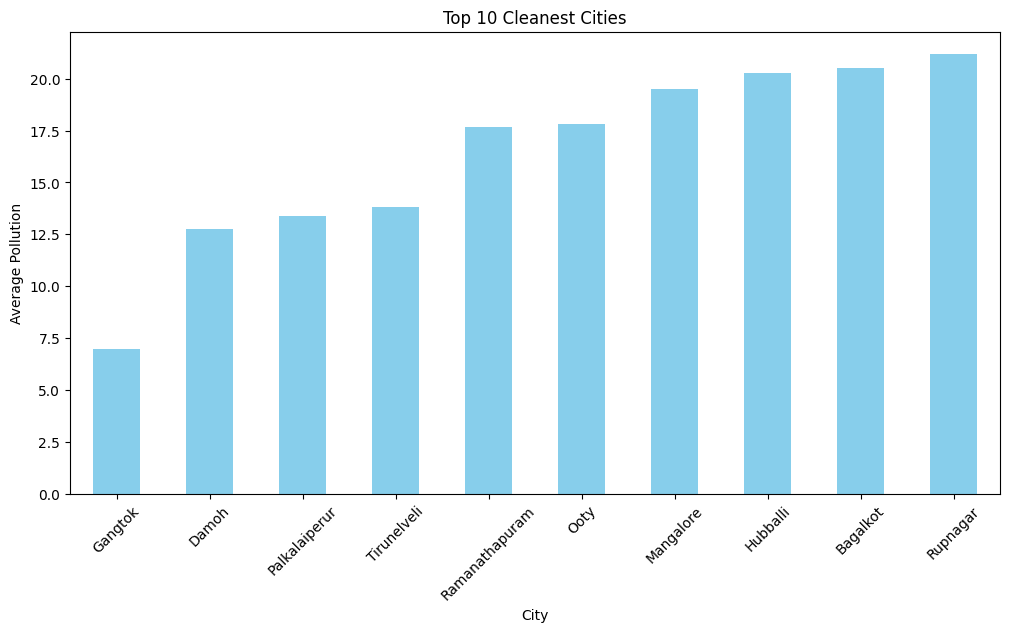

In [24]:
# ==========================================
# Top 10 Cleanest Cities
# ==========================================

clean_cities = df.groupby('city')['pollutant_avg'].mean().sort_values().head(10)

plt.figure(figsize=(12,6))

clean_cities.plot(kind='bar', color='skyblue')

plt.title("Top 10 Cleanest Cities")

plt.xlabel("City")
plt.ylabel("Average Pollution")

plt.xticks(rotation=45)

plt.savefig("../images/top_cleanest_cities.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

### Observation

- Some cities maintain significantly lower pollution levels compared to others.
- Cleaner cities may have better environmental policies and lower industrial emissions.
- This analysis helps identify environmentally healthier regions.